##  당신은 프라이버시를 파시겠습니까?

소득, 주관적 계층의식, 만족감이 
개인정보 제공에 미치는 영향 분석


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from IPython.display import display

## 1. 데이터 불러오기

In [3]:
dt = pd.read_csv("/home/pck/data_jour/sda_Team Project_/kgss2025.csv")

print(dt.shape)
display(dt.head())


(1211, 3491)


,YEAR,RESPID,YRRESPID,FINALWT,SEX,AGE,MARITAL,EMPLY,WHYNOE,EDUC,...,HHDNO,HOMPOP,SEPAPOP,UNRELAT,COHAP,REGION,URBAN,SAMPLEAB,INTDATM,INTDATD
0,2025.0,101.0,202500101.0,1.349140,1.0,44.0,1.0,1.0,-1.0,4.0,...,11.0,3.0,0.0,0.0,-1.0,1.0,1.0,1.0,4.0,6.0
1,2025.0,102.0,202500102.0,0.719461,2.0,62.0,1.0,2.0,3.0,3.0,...,2.0,2.0,0.0,0.0,-1.0,1.0,1.0,2.0,4.0,6.0
2,2025.0,103.0,202500103.0,0.572766,2.0,50.0,1.0,2.0,18.0,3.0,...,4.0,3.0,0.0,0.0,-1.0,1.0,1.0,2.0,4.0,7.0
3,2025.0,104.0,202500104.0,1.093403,1.0,62.0,1.0,1.0,-1.0,3.0,...,10.0,2.0,0.0,0.0,-1.0,1.0,1.0,2.0,5.0,25.0
4,2025.0,105.0,202500105.0,1.093403,1.0,74.0,1.0,2.0,19.0,2.0,...,12.0,2.0,0.0,0.0,-1.0,1.0,1.0,2.0,4.0,8.0


In [9]:
analysis_vars_raw = [
    "GIVEPIFR",
    "INCOM0", "RANK", "SATFIN",
    "AGE", "SEX", "EDUC", "ABLITINF", "TECHHARM",
    "FINALWT",
]

# kgss 2025 자료 전체인 dt에서 본 연구 분석에 필요한 변수만 선택하여 adt를 구성한다.
adt = dt[analysis_vars_raw].copy()

print(f"원자료 dt 행/열 수: {dt.shape}")
print(f"분석 변수만 선택한 adt 행/열 수: {adt.shape}")
display(adt.describe().T)


원자료 dt 행/열 수: (1211, 3491)
분석 변수만 선택한 adt 행/열 수: (1211, 10)


,count,mean,std,min,25%,50%,75%,max
GIVEPIFR,1211.0,3.507019,1.121057,-8.000000,3.000000,4.00000,4.000000,5.000000
INCOM0,1211.0,448.386457,407.973516,-8.000000,216.000000,400.00000,600.000000,9000.000000
RANK,1211.0,5.065235,1.498717,1.000000,4.000000,5.00000,6.000000,10.000000
SATFIN,1211.0,3.182494,0.886384,1.000000,3.000000,3.00000,4.000000,5.000000
AGE,1211.0,52.611891,15.651251,18.000000,40.000000,54.00000,64.000000,93.000000
SEX,1211.0,1.610239,0.487897,1.000000,1.000000,2.00000,2.000000,2.000000
EDUC,1211.0,3.469860,1.483142,-8.000000,3.000000,3.00000,5.000000,8.000000
ABLITINF,1211.0,2.347647,1.545626,-8.000000,2.000000,2.00000,3.000000,5.000000
TECHHARM,1211.0,3.321222,0.988381,-8.000000,3.000000,3.00000,4.000000,5.000000
FINALWT,1211.0,1.000000,0.611764,0.286383,0.636851,0.87153,1.256653,5.287165


## 2. 데이터 전처리

- `-8`은 공통 결측 코드로 처리한다.
- `ABLITINF`의 `-1`은 비해당으로 보고 결측 처리한다.
- `GIVEPIFR`, `SATFIN`, `ABLITINF`, `TECHHARM`은 분석 방향에 맞게 역코딩한다.
- `INCOM0`는 `log_INCOM0 = log(INCOM0 + 1)`로 변환한다.

In [10]:
# FINALWT는 이후 WLS 회귀분석에서 표본가중치로 사용한다.

# 공통 결측 코드 처리
for col in analysis_vars_raw:
    adt[col] = adt[col].replace(-8, np.nan)

# ABLITINF의 -1은 비해당으로 보고 결측 처리
adt["ABLITINF"] = adt["ABLITINF"].replace(-1, np.nan)

# 종속변수 개인정보 제공 태도 역코딩
# 분석척도는 1=매우 반대, 5=매우 동의  GIVEPIFR_R: 1=매우반대, 5= 매우동의
adt["GIVEPIFR_R"] = np.where(adt["GIVEPIFR"].isin([1, 2, 3, 4, 5]), 6 - adt["GIVEPIFR"], np.nan)

# 독립변수/통제변수 역코딩
# SATFIN_R: 1=매우 불만족, 5=매우 만족
# ABLITINF_R: 1=매우 낮음, 5=매우 높음
for v in ["SATFIN", "ABLITINF"]:
    adt[f"{v}_R"] = np.where(adt[v].isin([1, 2, 3, 4, 5]), 6 - adt[v], np.nan)

# TECHHARM_R: 값이 높을수록 기술위험 인식이 높도록 역코딩
adt["TECHHARM_R"] = np.where(adt["TECHHARM"].isin([1, 2, 3, 4, 5]), 6 - adt["TECHHARM"], np.nan)

# INCOM0 변수 로그 변환
adt["log_INCOM0"] = np.log1p(adt["INCOM0"].where(adt["INCOM0"] >= 0, np.nan))

# EDUC -> EDUC_GROUP
# 고졸 이하: 0=무학, 1=초등학교, 2=중학교, 3=고등학교, 8=서당한학 / 2년제 대학: 4=전문대학 / 4년제 대학: 5=대학교 / 대학원 이상: 6=대학원 석사, 7=대학원 박사
educ_categories = ["고졸 이하", "2년제 대학", "4년제 대학", "대학원 이상"]
adt["EDUC_GROUP"] = pd.Series(pd.NA, index=adt.index, dtype="object")
adt.loc[adt["EDUC"].isin([0, 1, 2, 3, 8]), "EDUC_GROUP"] = "고졸 이하"
adt.loc[adt["EDUC"].eq(4), "EDUC_GROUP"] = "2년제 대학"
adt.loc[adt["EDUC"].eq(5), "EDUC_GROUP"] = "4년제 대학"
adt.loc[adt["EDUC"].isin([6, 7]), "EDUC_GROUP"] = "대학원 이상"
adt["EDUC_GROUP"] = pd.Categorical(adt["EDUC_GROUP"], categories=educ_categories, ordered=True)


display(adt.head())
display(adt[["GIVEPIFR", "GIVEPIFR_R", "SATFIN_R", "ABLITINF_R", "log_INCOM0", "EDUC", "EDUC_GROUP", "TECHHARM_R"]].head())
display(adt.isna().sum())


,GIVEPIFR,INCOM0,RANK,SATFIN,AGE,SEX,EDUC,ABLITINF,TECHHARM,FINALWT,GIVEPIFR_R,SATFIN_R,ABLITINF_R,TECHHARM_R,log_INCOM0,EDUC_GROUP
0,3.0,600.0,4.0,4.0,44.0,1.0,4.0,2.0,2.0,1.349140,3.0,2.0,4.0,4.0,6.398595,2년제 대학
1,2.0,280.0,4.0,4.0,62.0,2.0,3.0,2.0,4.0,0.719461,4.0,2.0,4.0,2.0,5.638355,고졸 이하
2,3.0,250.0,5.0,3.0,50.0,2.0,3.0,2.0,2.0,0.572766,3.0,3.0,4.0,4.0,5.525453,고졸 이하
3,2.0,NaN,2.0,4.0,62.0,1.0,3.0,2.0,3.0,1.093403,4.0,2.0,4.0,3.0,NaN,고졸 이하
4,4.0,320.0,3.0,5.0,74.0,1.0,2.0,3.0,3.0,1.093403,2.0,1.0,3.0,3.0,5.771441,고졸 이하


,GIVEPIFR,GIVEPIFR_R,SATFIN_R,ABLITINF_R,log_INCOM0,EDUC,EDUC_GROUP,TECHHARM_R
0,3.0,3.0,2.0,4.0,6.398595,4.0,2년제 대학,4.0
1,2.0,4.0,2.0,4.0,5.638355,3.0,고졸 이하,2.0
2,3.0,3.0,3.0,4.0,5.525453,3.0,고졸 이하,4.0
3,2.0,4.0,2.0,4.0,NaN,3.0,고졸 이하,3.0
4,4.0,2.0,1.0,3.0,5.771441,2.0,고졸 이하,3.0


GIVEPIFR       1
INCOM0        60
RANK           0
SATFIN         0
AGE            0
SEX            0
EDUC           1
ABLITINF      88
TECHHARM       1
FINALWT        0
GIVEPIFR_R     1
SATFIN_R       0
ABLITINF_R    88
TECHHARM_R     1
log_INCOM0    60
EDUC_GROUP     1
dtype: int64

In [ ]:
# NaN 값 제거

# 전처리한 변수들
analysis_vars = [
    "GIVEPIFR_R",
    "log_INCOM0", "RANK", "SATFIN_R",
    "AGE", "SEX", "EDUC_GROUP", "ABLITINF_R", "TECHHARM_R",
    "FINALWT",
]


adt_before_drop_n = len(adt)
adt = adt.dropna(subset=analysis_vars).copy().reset_index(drop=True)

print(f"결측 제거 전 adt 행 수: {adt_before_drop_n}")
print(f"결측 제거 후 adt 행 수: {len(adt)}")
print(f"제거된 행 수: {adt_before_drop_n - len(adt)}")

# 최종 분석 표본 1,069명
display(adt.head())
display(adt[analysis_vars].isna().sum())


결측 제거 전 adt 행 수: 1211
결측 제거 후 adt 행 수: 1069
제거된 행 수: 142


,GIVEPIFR,INCOM0,RANK,SATFIN,AGE,SEX,EDUC,ABLITINF,TECHHARM,FINALWT,GIVEPIFR_R,SATFIN_R,ABLITINF_R,TECHHARM_R,log_INCOM0,EDUC_GROUP
0,3.0,600.0,4.0,4.0,44.0,1.0,4.0,2.0,2.0,1.349140,3.0,2.0,4.0,4.0,6.398595,2년제 대학
1,2.0,280.0,4.0,4.0,62.0,2.0,3.0,2.0,4.0,0.719461,4.0,2.0,4.0,2.0,5.638355,고졸 이하
2,3.0,250.0,5.0,3.0,50.0,2.0,3.0,2.0,2.0,0.572766,3.0,3.0,4.0,4.0,5.525453,고졸 이하
3,4.0,320.0,3.0,5.0,74.0,1.0,2.0,3.0,3.0,1.093403,2.0,1.0,3.0,3.0,5.771441,고졸 이하
4,2.0,300.0,4.0,4.0,53.0,2.0,3.0,3.0,4.0,0.572766,4.0,2.0,3.0,2.0,5.707110,고졸 이하


GIVEPIFR_R    0
log_INCOM0    0
RANK          0
SATFIN_R      0
AGE           0
SEX           0
EDUC_GROUP    0
ABLITINF_R    0
TECHHARM_R    0
FINALWT       0
dtype: int64

## 3. 기술통계와 기초 분석

### 모든 분석 변수의 기초 요약값 (보고서 3.5 부분)

In [13]:
summary_vars = [
    "GIVEPIFR_R",
    "INCOM0", "log_INCOM0", "RANK", "SATFIN_R",
    "AGE", "ABLITINF_R", "TECHHARM_R", "FINALWT",
]

basic_numeric_summary = adt[summary_vars].describe().T
basic_numeric_summary = basic_numeric_summary[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
display(basic_numeric_summary)

# 범주형 혼동변수: 성별과 교육수준의 빈도 및 비율
sex_summary = pd.DataFrame({
    "count": adt["SEX"].value_counts().sort_index(),
    "percent": (adt["SEX"].value_counts(normalize=True).sort_index() * 100).round(2),
})
sex_summary.index.name = "SEX"
display(sex_summary)

educ_summary = pd.DataFrame({
    "count": adt["EDUC_GROUP"].value_counts().reindex(educ_categories),
    "percent": (adt["EDUC_GROUP"].value_counts(normalize=True).reindex(educ_categories) * 100).round(2),
})
educ_summary.index.name = "EDUC_GROUP"
display(educ_summary)


,count,mean,std,min,25%,50%,75%,max
GIVEPIFR_R,1069.0,2.507951,1.067560,1.000000,2.000000,2.000000,3.00000,5.000000
INCOM0,1069.0,498.745557,407.195596,0.000000,280.000000,420.000000,650.00000,9000.000000
log_INCOM0,1069.0,5.985669,0.739965,0.000000,5.638355,6.042633,6.47851,9.105091
RANK,1069.0,5.106642,1.482053,1.000000,4.000000,5.000000,6.00000,10.000000
SATFIN_R,1069.0,2.824135,0.872455,1.000000,2.000000,3.000000,3.00000,5.000000
AGE,1069.0,51.145931,14.304776,19.000000,40.000000,53.000000,62.00000,93.000000
ABLITINF_R,1069.0,3.351731,1.131664,1.000000,3.000000,3.000000,4.00000,5.000000
TECHHARM_R,1069.0,2.669785,0.937381,1.000000,2.000000,3.000000,3.00000,5.000000
FINALWT,1069.0,0.996745,0.582374,0.286383,0.637936,0.871530,1.27335,5.287165


,count,percent
SEX,,
1.0,419,39.2
2.0,650,60.8


,count,percent
EDUC_GROUP,,
고졸 이하,549,51.36
2년제 대학,169,15.81
4년제 대학,318,29.75
대학원 이상,33,3.09


### 주요 변수의 이변량 관계 (보고서 4.1 부분)


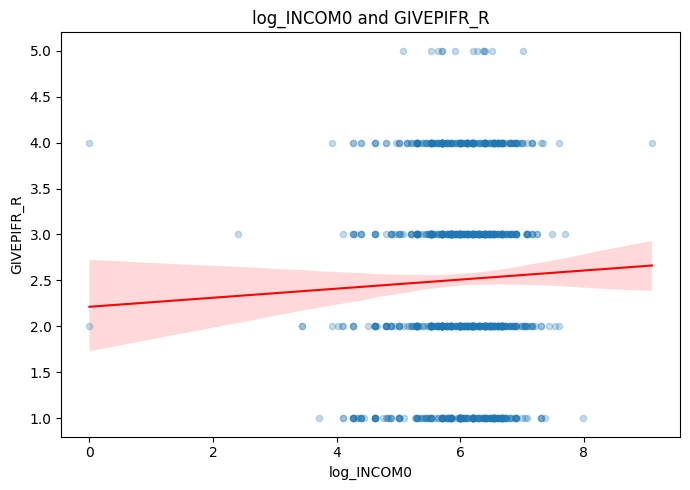

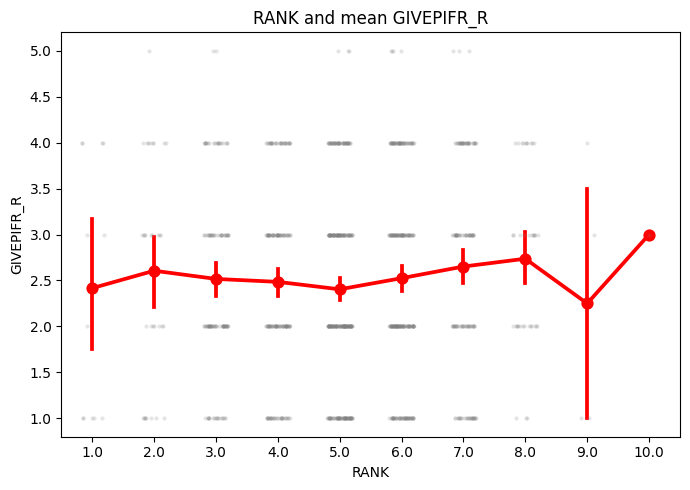

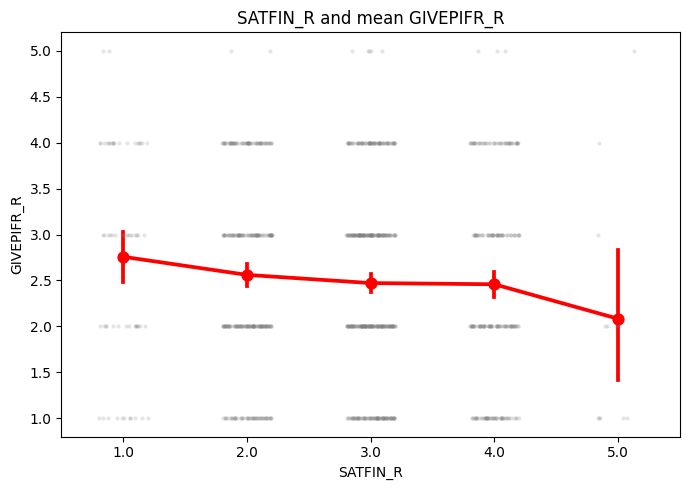

In [15]:
# 핵심 독립변수와 개인정보 제공 동의의 관계 시각화
plt.figure(figsize=(7, 5))
sns.regplot(
    data=adt,
    x="log_INCOM0",
    y="GIVEPIFR_R",
    scatter_kws={"alpha": 0.25, "s": 20},
    line_kws={"color": "red", "linewidth": 1.5},
)
plt.title("log_INCOM0 and GIVEPIFR_R")
plt.xlabel("log_INCOM0")
plt.ylabel("GIVEPIFR_R")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
sns.stripplot(
    data=adt,
    x="RANK",
    y="GIVEPIFR_R",
    color="gray",
    alpha=0.20,
    jitter=0.20,
    size=3,
)
sns.pointplot(
    data=adt,
    x="RANK",
    y="GIVEPIFR_R",
    errorbar=("ci", 95),
    color="red",
    markers="o",
    linestyles="-",
)
plt.title("RANK and mean GIVEPIFR_R")
plt.xlabel("RANK")
plt.ylabel("GIVEPIFR_R")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
sns.stripplot(
    data=adt,
    x="SATFIN_R",
    y="GIVEPIFR_R",
    color="gray",
    alpha=0.20,
    jitter=0.20,
    size=3,
)
sns.pointplot(
    data=adt,
    x="SATFIN_R",
    y="GIVEPIFR_R",
    errorbar=("ci", 95),
    color="red",
    markers="o",
    linestyles="-",
)
plt.title("SATFIN_R and mean GIVEPIFR_R")
plt.xlabel("SATFIN_R")
plt.ylabel("GIVEPIFR_R")
plt.tight_layout()
plt.show()


## 4. WLS 회귀분석 

In [18]:
# 분석 1: log_INCOM0 + 통제변수 -> 가설 1 검증
formula_analysis1 = (
    "GIVEPIFR_R ~ log_INCOM0 + AGE + C(SEX) + C(EDUC_GROUP) + ABLITINF_R + TECHHARM_R"
)
analysis1_model = smf.wls(
    formula=formula_analysis1,
    data=adt,
    weights=adt["FINALWT"]
).fit()

# 분석 2: RANK + 통제변수 -> 가설 2 검증
formula_analysis2 = (
    "GIVEPIFR_R ~ RANK + AGE + C(SEX) + C(EDUC_GROUP) + ABLITINF_R + TECHHARM_R"
)
analysis2_model = smf.wls(
    formula=formula_analysis2,
    data=adt,
    weights=adt["FINALWT"]
).fit()

# 분석 3: SATFIN_R + 통제변수 -> 가설 3 검증
formula_analysis3 = (
    "GIVEPIFR_R ~ SATFIN_R + AGE + C(SEX) + C(EDUC_GROUP) + ABLITINF_R + TECHHARM_R"
)
analysis3_model = smf.wls(
    formula=formula_analysis3,
    data=adt,
    weights=adt["FINALWT"]
).fit()

# 분석 4: log_INCOM0, RANK, SATFIN_R + 통제변수 -> 가설 4 검증
formula_analysis5 = (
    "GIVEPIFR_R ~ log_INCOM0 + RANK + SATFIN_R + AGE "
    "+ C(SEX) + C(EDUC_GROUP) + ABLITINF_R + TECHHARM_R"
)
analysis5_model = smf.wls(
    formula=formula_analysis5,
    data=adt,
    weights=adt["FINALWT"]
).fit()


# 사후분석: RANK, SATFIN_R + 통제변수
formula_analysis4 = (
    "GIVEPIFR_R ~ RANK + SATFIN_R + AGE "
    "+ C(SEX) + C(EDUC_GROUP) + ABLITINF_R + TECHHARM_R"
)
analysis4_model = smf.wls(
    formula=formula_analysis4,
    data=adt,
    weights=adt["FINALWT"]
).fit()


models = {
    "ANALYSIS_1_WLS_GIVEPIFR_R_logINCOM0": analysis1_model,
    "ANALYSIS_2_WLS_GIVEPIFR_R_RANK": analysis2_model,
    "ANALYSIS_3_WLS_GIVEPIFR_R_SATFIN_R": analysis3_model,
    "ANALYSIS_4_WLS_GIVEPIFR_R_all": analysis4_model,
    "ANALYSIS_5_WLS_GIVEPIFR_R_Post": analysis5_model,
}

# 전체 회귀표
for model_name, model in models.items():
    print("=" * 100)
    print(model_name)
    print(model.summary())


ANALYSIS_1_WLS_GIVEPIFR_R_logINCOM0
                            WLS Regression Results                            
Dep. Variable:             GIVEPIFR_R   R-squared:                       0.054
Model:                            WLS   Adj. R-squared:                  0.047
Method:                 Least Squares   F-statistic:                     7.623
Date:                Fri, 12 Jun 2026   Prob (F-statistic):           5.94e-10
Time:                        01:54:49   Log-Likelihood:                -1639.4
No. Observations:                1069   AIC:                             3297.
Df Residuals:                    1060   BIC:                             3342.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------

## 추가 `INCOM0` 분포 시각화

,variable,n,mean,median,std,min,p25,p75,max
0,INCOM0,1069,498.75,420.0,407.2,0.0,280.0,650.0,9000.0


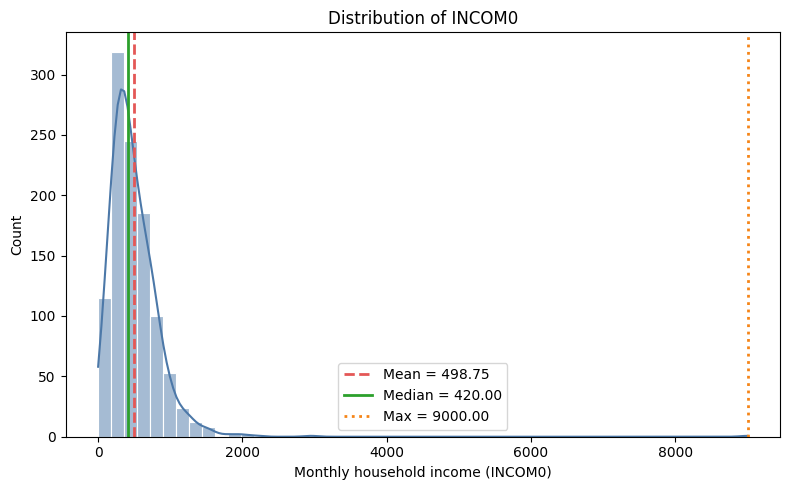

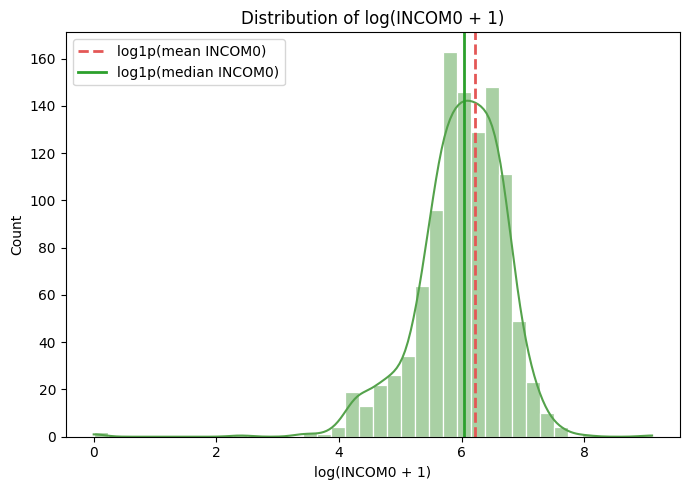

In [19]:
# INCOM0 분포 시각화
incom0_dist = adt["INCOM0"].dropna()

incom0_mean = incom0_dist.mean()
incom0_median = incom0_dist.median()
incom0_max = incom0_dist.max()

incom0_summary = pd.DataFrame({
    "variable": ["INCOM0"],
    "n": [len(incom0_dist)],
    "mean": [incom0_mean],
    "median": [incom0_median],
    "std": [incom0_dist.std()],
    "min": [incom0_dist.min()],
    "p25": [incom0_dist.quantile(0.25)],
    "p75": [incom0_dist.quantile(0.75)],
    "max": [incom0_max],
})
display(incom0_summary.round(2))

plt.figure(figsize=(8, 5))
sns.histplot(incom0_dist, bins=50, kde=True, color="#4C78A8", edgecolor="white")
plt.axvline(incom0_mean, color="#E45756", linestyle="--", linewidth=2, label=f"Mean = {incom0_mean:.2f}")
plt.axvline(incom0_median, color="#2CA02C", linestyle="-", linewidth=2, label=f"Median = {incom0_median:.2f}")
plt.axvline(incom0_max, color="#F58518", linestyle=":", linewidth=2, label=f"Max = {incom0_max:.2f}")
plt.title("Distribution of INCOM0")
plt.xlabel("Monthly household income (INCOM0)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

# 로그 변환 후 분포
plt.figure(figsize=(7, 5))
sns.histplot(np.log1p(incom0_dist), bins=40, kde=True, color="#54A24B", edgecolor="white")
plt.axvline(np.log1p(incom0_mean), color="#E45756", linestyle="--", linewidth=2, label="log1p(mean INCOM0)")
plt.axvline(np.log1p(incom0_median), color="#2CA02C", linestyle="-", linewidth=2, label="log1p(median INCOM0)")
plt.title("Distribution of log(INCOM0 + 1)")
plt.xlabel("log(INCOM0 + 1)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()
